In [1]:
# Check GPU type
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [1]:
import tensorflow as tf

cifar = tf.keras.datasets.cifar100
(x_train, y_train), (x_test, y_test) = cifar.load_data()
model = tf.keras.applications.ResNet50(
    include_top=True,
    weights=None,
    input_shape=(32, 32, 3),
    classes=100,)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5, batch_size=64)

Matplotlib is building the font cache; this may take a moment.


KeyboardInterrupt: 

In [1]:
import sys

import tensorflow as tf
import platform

print(f"Python Platform: {platform.platform()}")
print(f"Tensor Flow Version: {tf.__version__}")
print()
print(f"Python {sys.version}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

Python Platform: macOS-15.1-arm64-arm-64bit
Tensor Flow Version: 2.19.0

Python 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
GPU is available


In [3]:
# Install ultralytics
!pip -q install  ultralytics

In [2]:
# Import libraries
import pandas as pd
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import cv2
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
import multiprocessing
import numpy as np
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/adjei/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
## Drop the Folder if it already exists
DATASETS_DIR = Path('dataset')
DATASETS_DIR

In [ ]:
# Image & labels directory
TRAIN_IMAGES_DIR = DATASETS_DIR / 'images' / 'train'
TRAIN_LABELS_DIR = DATASETS_DIR / 'labels'/ 'train'
TEST_IMAGES_DIR = DATASETS_DIR / 'images' / 'test'
VAL_IMAGES_DIR = DATASETS_DIR / 'images' /'val'
VAL_LABELS_DIR = DATASETS_DIR / 'labels' /'val'

In [ ]:
# Check if DATASETS_DIR exists, if it does delete it and recreate it
for DIR in [TRAIN_IMAGES_DIR, VAL_IMAGES_DIR, TEST_IMAGES_DIR, VAL_LABELS_DIR, DATASETS_DIR]:
  if DIR.exists():
    shutil.rmtree(DIR)
  DIR.mkdir(parents=True, exist_ok = True)

In [ ]:
# Unpack the 'dataset.zip'
shutil.unpack_archive(INPUT_DATA_DIR / 'dataset.zip', DATASETS_DIR)

In [ ]:
def count_files(directory):
    total_files = 0
    for root, _, files in os.walk(directory):
        total_files += len(files)
    return total_files

In [ ]:
## Count the number files in TRAIN_IMAGES_DIR
num_train_images = count_files(TRAIN_IMAGES_DIR)
print(f"There are {num_train_images} in {TRAIN_IMAGES_DIR}")

In [ ]:
## Count the number of files in TRAIN_LABELS_DIR
num_train_labels = count_files(TRAIN_LABELS_DIR)
print(f"There are {num_train_labels} in {TRAIN_LABELS_DIR}")

In [ ]:
## Get the set of all the stems of the images in TRAIN_IMAGES_DIR
train_images_stems = set([str(Path(name).stem) for name in os.listdir(TRAIN_IMAGES_DIR)])
len(train_images_stems)

In [ ]:
## Get the set of all the stems of the labes in TRAIN_LABELS_DIR
train_labels_stems = set([str(Path(name).stem) for name in os.listdir(TRAIN_LABELS_DIR)])
len(train_labels_stems)

In [ ]:
# Check that the two sets are identitical
train_images_stems == train_labels_stems

In [ ]:
TRAIN_IMAGES_DIR.absolute()

In [3]:
# Load train and test files
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
ss = pd.read_csv('SampleSubmission.csv')

In [4]:
## Sample submission file
ss.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax
0,ID_Genxyu.jpg,healthy,0.5,100,100,100,100
1,ID_svY6TG.jpg,healthy,0.5,100,100,100,100
2,ID_d0gpda.jpg,healthy,0.5,100,100,100,100
3,ID_frWmBT.jpg,healthy,0.5,100,100,100,100
4,ID_TaRW6o.jpg,healthy,0.5,100,100,100,100


In [5]:
train.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg


In [6]:
train['class'].unique()

array(['healthy', 'anthracnose', 'cssvd'], dtype=object)

In [7]:
train['class_id'].unique()

array([2, 0, 1])

In [8]:
train[['class', 'class_id']].value_counts()

class        class_id
healthy      2           4279
cssvd        1           3223
anthracnose  0           2271
cssvd        0             18
healthy      1              1
Name: count, dtype: int64

In [9]:
class_map = {cls: i for i, cls in enumerate(sorted(train['class'].unique().tolist()))}
class_map

{'anthracnose': 0, 'cssvd': 1, 'healthy': 2}

In [10]:
# Strip any spacing from the class item and make sure that it is a str
train['class'] = train['class'].str.strip()

# Map {'healthy': 2, 'cssvd': 1, anthracnose: 0}
train['class_id'] = train['class'].map(class_map)

In [11]:
train[['class', 'class_id']].value_counts()

class        class_id
healthy      2           4280
cssvd        1           3241
anthracnose  0           2271
Name: count, dtype: int64

In [12]:
# Number of unique images path
train['ImagePath'].nunique()

5529

In [13]:
# Split the train dataset into train_df & val_df
train_names, val_names = train_test_split(train['Image_ID'].unique(), test_size=0.15, random_state=42)

train_df = train[train['Image_ID'].isin(train_names)]
val_df = train[train['Image_ID'].isin(val_names)]

In [14]:
train_df.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg


In [15]:
train_df.shape, val_df.shape, test.shape

((8236, 9), (1556, 9), (1626, 9))

In [16]:
ss.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax
0,ID_Genxyu.jpg,healthy,0.5,100,100,100,100
1,ID_svY6TG.jpg,healthy,0.5,100,100,100,100
2,ID_d0gpda.jpg,healthy,0.5,100,100,100,100
3,ID_frWmBT.jpg,healthy,0.5,100,100,100,100
4,ID_TaRW6o.jpg,healthy,0.5,100,100,100,100


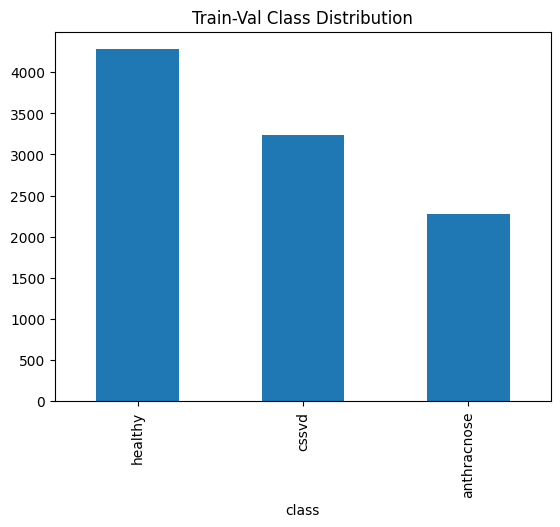

In [17]:
# Preview target distribution, seems there a class imbalance that needs to be handled
train['class'].value_counts().plot(kind='bar')
plt.title('Train-Val Class Distribution')
plt.show();

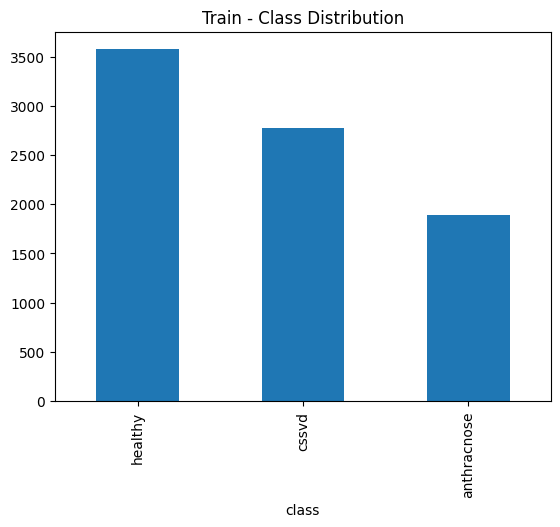

In [18]:
train_df['class'].value_counts().plot(kind='bar')
plt.title('Train - Class Distribution')
plt.show();

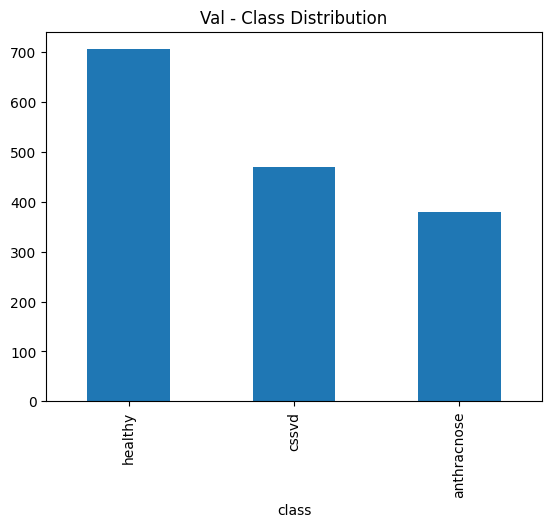

In [19]:
val_df['class'].value_counts().plot(kind='bar')
plt.title('Val - Class Distribution')
plt.show();

In [ ]:
# Create a data.yaml file required by yolo
class_names = sorted(train['class'].unique().tolist())
num_classes = len(class_names)

data_yaml = {
    "path" : str(DATASETS_DIR.absolute()),
    'train': str(TRAIN_IMAGES_DIR.absolute()),
    'val': str(VAL_IMAGES_DIR.absolute()),
    'test': str(TEST_IMAGES_DIR.absolute()),
    'nc': num_classes,
    'names': class_names
}

yaml_path = 'data.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(data_yaml, file, default_flow_style=False)

# Preview data yaml file
data_yaml

In [21]:
len(val_names), len(set(val_names))

(830, 830)

In [22]:
val_image_names = [str(Path(name).stem) for name in val_df['Image_ID'].unique()]

In [23]:
len(val_image_names)

830

In [ ]:
# list of images in TRAIN_IMAGES_DIR
images_in_train_dir = os.listdir(TRAIN_IMAGES_DIR)
len(images_in_train_dir), len(train_names)

In [24]:
train_image_names = [str(Path(name).stem) for name in train['ImagePath'].unique()]

In [25]:
len(train_image_names)

5529

In [ ]:
# Check that VAL_IMAGES_DIR & VAL_LABELS_DIR exist if not create them
for DIR in [VAL_IMAGES_DIR, VAL_LABELS_DIR]:
  if not DIR.exists():
    DIR.mkdir(parents=True, exist_ok = True)

In [ ]:
# Copy images in val_names to dataset/val and do the same with the labels
for image_name in tqdm(val_names):
    shutil.move(TRAIN_IMAGES_DIR / image_name, VAL_IMAGES_DIR / image_name)
    img_ext = image_name.split('.')[-1]
    label_name = image_name.replace(f'.{img_ext}', '.txt')
    shutil.move(TRAIN_LABELS_DIR / label_name, VAL_LABELS_DIR / label_name)

In [ ]:
# Plot some images and their bboxes to ensure the conversion was done correctly
def load_annotations(label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
    boxes = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        boxes.append((class_id, x_center, y_center, width, height))
    return boxes

# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image_path, boxes):
    # Load the image
    image = np.array(Image.open(str(image_path)))


    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        class_id, x_center, y_center, width, height = box
        # Convert YOLO format to corner coordinates
        xmin = int((x_center - width / 2) * w)
        ymin = int((y_center - height / 2) * h)
        xmax = int((x_center + width / 2) * w)
        ymax = int((y_center + height / 2) * h)

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=8, weight='bold')

    plt.axis('off')
    plt.show()

# Directories for images and labels
IMAGE_DIR = TRAIN_IMAGES_DIR
LABEL_DIR = TRAIN_LABELS_DIR

# Plot a few images with their annotations
for image_name in os.listdir(IMAGE_DIR)[:5]:
    image_path = IMAGE_DIR / image_name
    img_ext = image_name.split('.')[-1]
    label_path = LABEL_DIR / (image_name.replace(f'.{img_ext}', '.txt'))

    if label_path.exists():
        boxes = load_annotations(label_path)
        print(f"Plotting {image_name} with {len(boxes)} bounding boxes.")
        plot_image_with_boxes(image_path, boxes)
    else:
        print(f"No annotations found for {image_name}.")


In [ ]:
# Load a yolo pretrained model
model = YOLO('yolov8n.pt')

# Fine tune model to our data
model.train(
    data='data.yaml',          # Path to the dataset configuration
    epochs=10,                 # Number of epochs
    imgsz=1024,                # Image size (height, width)
    batch=8,                   # Batch size
    device=0,                  # Device to use (0 for the first GPU)
    patience=5)

In [ ]:
# Validate the model on the validation set
model = YOLO('/content/runs/detect/train/weights/best.pt')
results = model.val()

In [ ]:
# Load the trained YOLO model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Path to the test images directory
test_dir_path = TEST_IMAGES_DIR

# Get a list of all image files in the test directory
image_files = os.listdir(test_dir_path)

# Initialize an empty list to store the results for all images
all_data = []

# Initialize an empty list to store the results for all images
all_data = []

# Iterate through each image in the directory
for image_file in tqdm(image_files):
    # Full path to the image
    img_path = os.path.join(test_dir_path, image_file)

    # Make predictions on the image
    results = model(img_path)

    # Extract bounding boxes, confidence scores, and class labels
    boxes = results[0].boxes.xyxy.tolist() if results[0].boxes else []  # Bounding boxes in xyxy format
    classes = results[0].boxes.cls.tolist() if results[0].boxes else []  # Class indices
    confidences = results[0].boxes.conf.tolist() if results[0].boxes else []  # Confidence scores
    names = results[0].names  # Class names dictionary

    if boxes:  # If detections are found
        for box, cls, conf in zip(boxes, classes, confidences):
            x1, y1, x2, y2 = box
            detected_class = names[int(cls)]  # Get the class name from the names dictionary

            # Add the result to the all_data list
            all_data.append({
                'Image_ID': str(image_file),
                'class': detected_class,
                'confidence': conf,
                'ymin': y1,
                'xmin': x1,
                'ymax': y2,
                'xmax': x2
            })
    else:  # If no objects are detected
        all_data.append({
            'Image_ID': str(image_file),
            'class': "None",
            'confidence': None,
            'ymin': None,
            'xmin': None,
            'ymax': None,
            'xmax': None
        })



In [ ]:
# Convert the list to a DataFrame for all images
sub = pd.DataFrame(all_data)

In [ ]:
sub.head()

In [ ]:
sub['class'].value_counts()

In [ ]:
# Create submission file to be uploaded to Zindi for scoring
sub.to_csv(f'{INPUT_DATA_DIR / "BenchmarkSubmission.csv"}', index = False)

In [ ]:
train['Image_ID'].nunique(), test['Image_ID'].nunique()

In [ ]:
train_df['Image_ID'].nunique() + val_df['Image_ID'].nunique() + test['Image_ID'].nunique()

In [ ]:
sub = pd.read_csv(f'{INPUT_DATA_DIR / "BenchmarkSubmission.csv"}')
sub.head()

In [ ]:
## Make a dataframe from all entries in sub with no detection
no_detection = sub[~sub['class'].isin(['cssvd', 'healthy', 'anthracnose'])]
no_detection

In [ ]:
# Get a random image from no_detection
rnd_no_detect_image = no_detection.sample(1)['Image_ID'].values[0]
rnd_no_detect_image

In [ ]:
# Plot the rnd_no_detect_image
image_path = TEST_IMAGES_DIR / rnd_no_detect_image
image = np.array(Image.open(str(image_path)))
plt.imshow(image);

In [ ]:
no_detection['Image_ID'].unique()

In [ ]:
# Plot each of the image in no_detection dataframe
for image_name in no_detection['Image_ID'].unique():
    image_path = TEST_IMAGES_DIR / image_name
    plt.title(image_name)
    image = np.array(Image.open(str(image_path)))
    plt.imshow(image)
    plt.show()
    print('--------------------------------------\n')